In [17]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os, json
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd().split("src")[0], "src"))
import core.functions
import core.models as models
import core.datagen as dg
import core.training as ct
import core.utils as utils
import core.ae_tools as aect
import core.mtl_tools as mtlct
from experiments.evolution._lib import id_eval
import experiments.mtl_cue_experiments as mtl_cue_experiments
from core.logger import logger

%load_ext autoreload
%autoreload
    
from IPython.display import clear_output, display

logger()

2026-08-24 02:33:52 | 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# stimuli

### head-gaussian stimuli

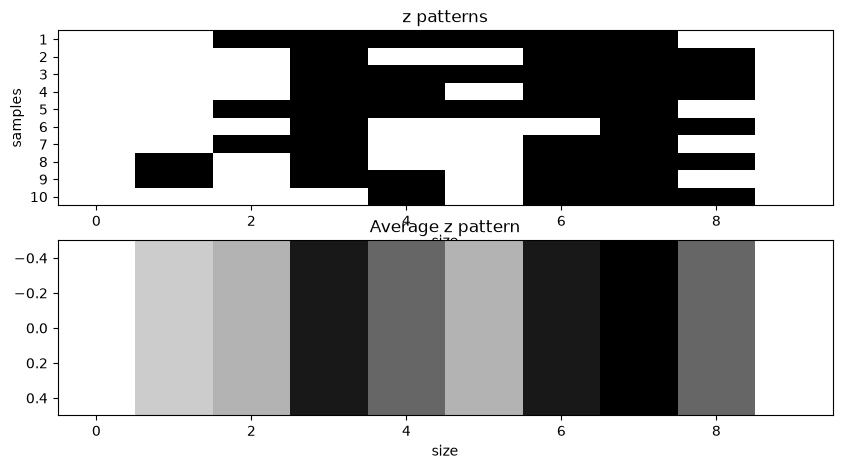

2026-08-23 17:12:48 | data:
[[0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 1. 0.]
 [0. 0. 1. 1. 0. 0. 1. 1. 0. 0.]
 [0. 1. 0. 1. 0. 0. 1. 1. 1. 0.]
 [0. 1. 0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1. 1. 0.]]
2026-08-23 17:12:48 | data:
[[0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 1. 0.]
 [0. 0. 1. 1. 0. 0. 1. 1. 0. 0.]
 [0. 1. 0. 1. 0. 0. 1. 1. 1. 0.]
 [0. 1. 0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1. 1. 0.]]


In [2]:
# setup
N = 10
size = 10
heads = 2
variance = 0.1
higher_heads = None
higher_variance = None
isplot = True

data = dg.stimulus_generator(N=N, size=size, heads=heads, variance=variance,
                             higher_heads=higher_heads, higher_variance=higher_variance,
                             plot=isplot, use_uniform=True)

logger(f"data:\n{data}")

### sparse stimuli

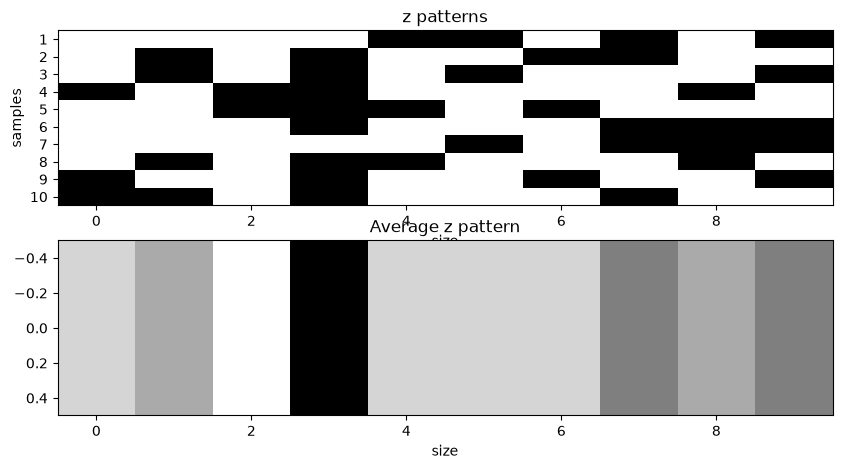

In [3]:
N = 10
K = 4
size = 10
isplot = True

data = dg.sparse_stimulus_generator(N=N, K=K, size=size, plot=isplot)


### gaussian place field activity

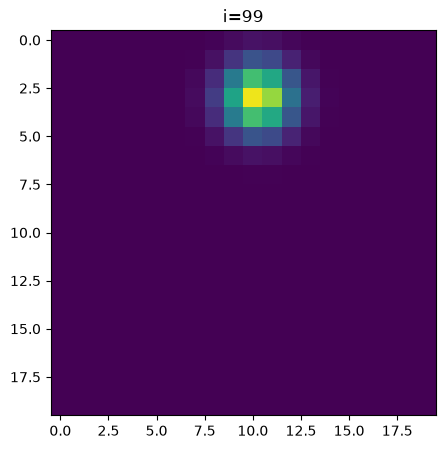

2026-08-20 15:12:51 | 


In [3]:
#data = dg.place_field_activity(N_x=20, N_y=20, sigma=1, xi=5, yi=5)

nx = 20
ny = 20

fig, ax = plt.subplots(figsize=(5, 5))

data = dg.place_field_activity(N_x=nx, N_y=ny, sigma=1, xi=5+nx/2, yi=5+ny/2)
data = dg.gaussian_activity((nx, ny), (5, 5), 3)
im = ax.imshow(data, vmin=0, vmax=1)
for i in range(100):

    clear_output(wait=True)
    ax.set_title(f"{i=}")

    data = dg.gaussian_activity((nx, ny), (7*np.cos(i)+ny/2, 7*np.sin(i)+ny/2), 3)
    #data = dg.place_field_activity(N_x=nx, N_y=ny, sigma=2, xi=7*np.cos(i)+nx/2, yi=7*np.sin(i)+ny/2)
    im.set_data(data)
    display(fig)
    
    plt.pause(0.1)

plt.close(fig)
logger() 


### circular track

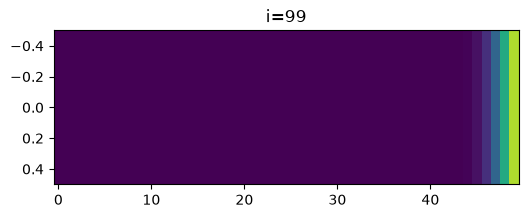

2026-08-23 17:12:59 | 
2026-08-23 17:12:59 | 


In [4]:
X = np.arange(50)

fig, ax = plt.subplots(figsize=(6, 2))

data = functions.gaussian_circular_distance(x1=X, x2=0, N=X.max(), sigma=2.).reshape(1, -1)
im = ax.imshow(data, vmin=0, vmax=1, aspect="auto")
for i in range(100):

    clear_output(wait=True)
    ax.set_title(f"{i=}")

    data = functions.gaussian_circular_distance(x1=X, x2=i, N=X.max(), sigma=2.).reshape(1, -1)
    im.set_data(data)
    display(fig)
    
    plt.pause(0.01)

plt.close(fig)
logger() 

### mec-lec observation

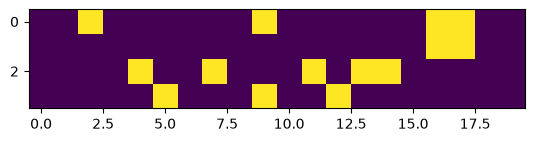

In [53]:
""" test lec pattern generation """
cue_patterns = dg.make_cues(n=4, size=20, fixed=False, p=0.2)

plt.imshow(cue_patterns)
plt.show()

2026-08-24 00:37:32 | 
2026-08-24 00:37:32 | 


[[1, 0], [1, 0], [1, 0], [0, 1], [1, 0]]


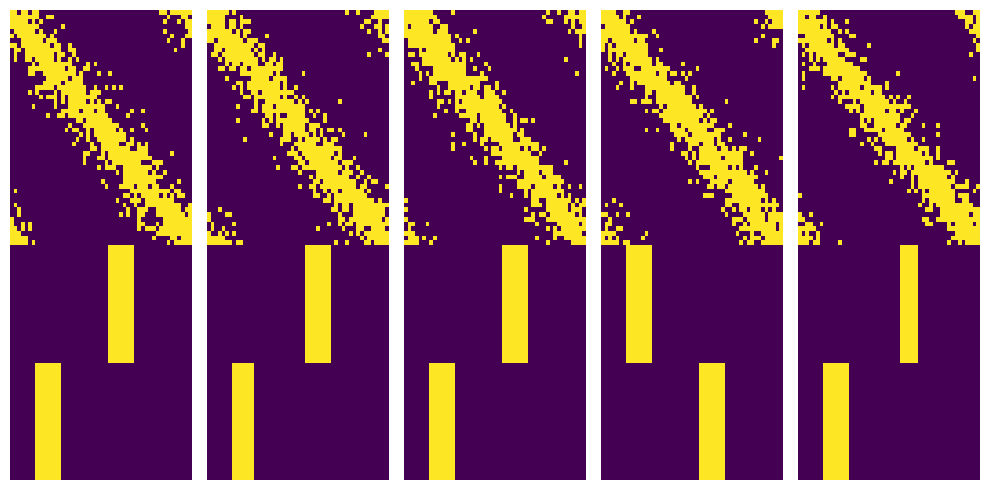

In [2]:
num_cue_patterns = 2
lec_size = 50
num_laps = 5
cue_positions = [10, 30]
cue_sequence = []
for l in range(num_laps):
   cue_sequence += [np.random.choice(list(range(num_cue_patterns)), replace=False, size=len(cue_positions)).tolist()] 

laps = {
    "n": 5,
    "length": 50, 
    "cues_positions": cue_positions, 
    "cues_patterns": dg.make_cues(n=num_cue_patterns, size=lec_size, fixed=True, p=0.1),
    "cues_sequence": cue_sequence,
    "cue_sigma": 2,
    "cue_alpha": 0.2,
    "cue_beta": 20.,
    "mec_binarized": True,
    "spacing": 2
}

data, laps_cus = dg.sparse_stimulus_generator_sensory(laps=laps, mec_sigma=5, lec_sigma=10)

logger()

fig, axs = plt.subplots(1, len(data), figsize=(2*len(data), 5), sharey=True)
fig.set_tight_layout({"h_pad": 0})
for d, ax in zip(data, axs):
    ax.imshow(d.T, aspect="auto")
    ax.axis('off')
plt.show()

spacing  4
num_laps  10
sequence  [[1, 2], [1, 2], [1, 2], [1, 2], [2, 3], [2, 3], [2, 3], [2, 3], [3, 0], [3, 0]]
[[1, 2], [1, 2], [1, 2], [1, 2], [2, 3], [2, 3], [2, 3], [2, 3], [3, 0], [3, 0]]


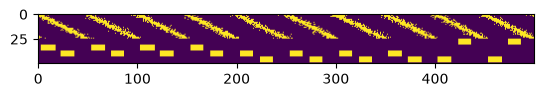

In [8]:
data = dg.make_cue_track_data(
        num_samples=500,
        size=50,
        num_cue_patterns = 4,
        lap_length= 50,
        cue_positions=[10, 30],
        cue_sigma=4,
        cue_beta=40,
        cue_alpha=0.2,
        mec_binarized=True,
        mec_sigma= 4,
        cue_spacing= 4)

plt.imshow(data.T);

#### gaussian \circ sigmoid

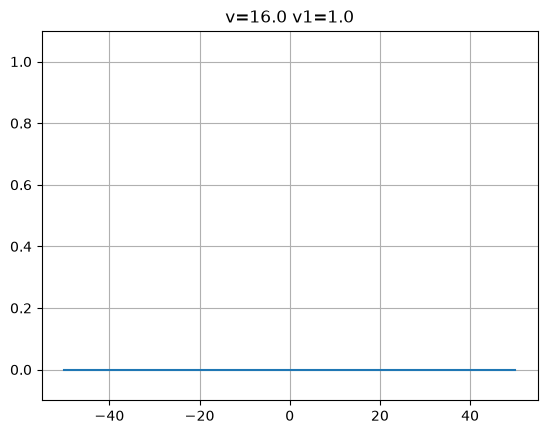

KeyboardInterrupt: 

In [6]:
beta = 2
alpha = 0.2
sigma = 10

num = 200
X = np.linspace(-50, 50, num)

f_sig = lambda x: 1/(1+np.exp(-beta*(x-alpha)))
f_gau = lambda x: np.exp(-0.5*(x/sigma)**2)
def func(x, v, v1):
    xi = np.exp(-0.5*(x/10)**2)
    return np.clip(2/(1+np.exp(-v*(xi-v1)))-1., 0, 1)

#Y = [f_sig(f_gau(xi)) for xi in X]
#plt.plot(X, Y);
var = np.linspace(2, 20, 10)
var1 = np.linspace(0, 1, 10)
Y = [func(xi, var[0], var[0]) for xi in X]

fig, ax = plt.subplots()

for t in range(100):
    for i in range(-len(var)+1, len(var), 1):
        v1 = var1[abs(i)]
        for j in range(-len(var)+1, len(var), 1):
            v = var[abs(j)]
    
            #Y = [func(xi, v, v1) for xi in X]
            Y = [functions.generalized_sigmoid(functions.gaussian_circular_distance(0, xi, 100, 10),
                                               v, v1, 2, 1) for xi in X]
        
            clear_output(wait=True)
            ax.clear()
            im = ax.plot(X, Y)
            ax.set_ylim((-0.1, 1.1))
            ax.set_title(f"{v=:.1f} {v1=:.1f}")
            ax.grid()
            display(fig)
            plt.pause(0.05)
plt.show()
    

# autoencoder

In [ ]:
ae = models.Autoencoder(input_dim=20, encoding_dim=10, K=10, beta=20., use_bias=True):


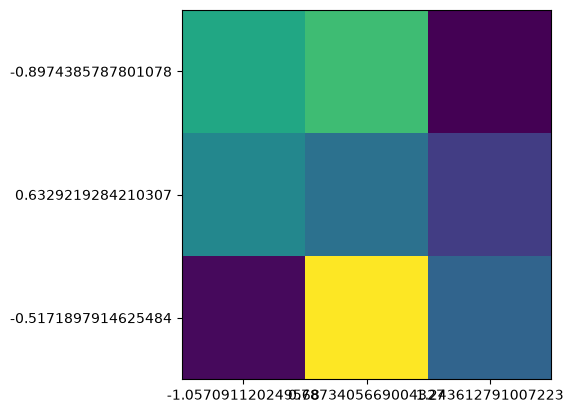

In [30]:
x = np.random.randn(3)
y = np.random.randn(3)
fig, ax = plt.subplots()
ax.imshow(np.random.randn(3, 3))
ax.set_xticks(range(3))
ax.set_xticklabels(x)
ax.set_yticks(range(3))
ax.set_yticklabels(y)
plt.show()

## track experiment

In [2]:
with open("../experiments/data/track_experiment.json", "r") as f:
    data = json.load(f)

data.k

dict_keys(['schema_version', 'description', 'metric_definition', 'settings', 'autoencoder_session', 'cue_assignments', 'aggregate', 'repetitions'])

In [5]:
data["schema_version"], data["description"], data["metric_definition"]

(1,
 'Continual MTL learning on circular laps with two cue identities swapped periodically between two positions.',
 {'recall_accuracy': 'mean over positions of clip(1 - sample MSE, 0, 1)',
  'recall_cosine': 'mean cosine similarity over positions',
  'matrix_axes': '[lap learned so far, recalled lap]'})

In [15]:
# setup
settings_sim = {
    "data_training_size": 50*10,
    "criterion": mtlct.cosine_criterion,
    "reps": 3,
    "use_bias": False,
    "disable": True,
    "plot": False,
    "ae_name": "ae_cue_nb_8"
}

settings_data = {
    "size": 50,
    "K": 5,
    "num_cue_patterns": 2,
    "lap_length": 50,
    "cue_positions": [10., 30.],
    "cue_sigma": 3.,
    "cue_beta": 40.,
    "cue_alpha": 0.2,
    "mec_binarized": True,
    "mec_sigma": 4,
    "cue_spacing": 5,
}

settings_mtl = {
    "K_ca3": 5,
    "K_lat": 15,
    "K_eo": 5,
    "dim_ca3": 50,
    "beta_is": 48,
    "beta_ca3": 196,
    "beta_ca1": 24,
    "beta_eo": 20,
    "alpha": 0.018,
    "nb_ei_ca3": 2,
    "num_swaps_ca1": 1,
    "num_swaps_ca3": 1,
    "random_IS": False,
    "plasticity": "base",
}

settings_mtl_err2 = {
    "K_ca3": 10,
    "dim_ca3": 50,
    "beta_ca3": 81,
    "beta_ca1": 38,
    "alpha": 0.022,
    "nb_ei_ca3": 2,
    "num_swaps_ca1": 1,
    "num_swaps_ca3": 1,
    "random_IS": False,
    "plasticity": "err2",
}

logger()

2026-08-24 02:32:31 | 


In [20]:
num_samples = settings_sim["data_training_size"]
ae_name = settings_sim.get("ae_name", "ae_cue_nb_0")
use_bias = settings_sim.get("use_bias", False)
plot = settings_sim.get("plot", False)
disable = settings_sim.get("disable", False)

autoencoder, info = aect.load_autoencoder(name=ae_name)
params = autoencoder.get_weights(bias=use_bias)

model = models.MTL(W_ei_ca1=params[0],
                   W_ca1_eo=params[1],
                   K_ca1=autoencoder._K_ca1,
                   K_eo=autoencoder._K_eo,
                   K_ca3=settings_mtl["K_ca3"],
                   dim_ca3=settings_mtl["dim_ca3"],
                   beta_is=autoencoder._beta_ei,
                   beta_ca3=settings_mtl["beta_ca3"],
                   beta_ca1=settings_mtl["beta_ca1"],
                   beta_eo=autoencoder._beta_eo,
                   alpha=settings_mtl["alpha"],
                   nb_ei_ca3=int(settings_mtl.get("nb_ei_ca3", 10)),
                   num_swaps_ca3=settings_mtl["num_swaps_ca3"],
                   num_swaps_ca1=settings_mtl["num_swaps_ca1"],
                   B_ei_ca1=params[2],
                   B_ca1_eo=params[3],
                   random_IS=settings_mtl["random_IS"],
                   plasticity=settings_mtl.get("plasticity", "base"))

reps = settings_sim.get("reps", 32)
criterion = settings_sim.get("criterion", mtlct.cosine_criterion)

results = np.zeros((reps, num_samples, num_samples))
rdisable = not(reps > 2)
# for r in tqdm(range(reps), disable=not(rdisable and (not disable))):
for r in tqdm(range(reps), disable=False):

    training_data = mtl_cue_experiments.make_cue_data(
        num_samples=num_samples,
        settings_data=settings_data,
    )

    logs, model = mtlct.train_for_accuracy(data=training_data,
                                           model=model,
                                           criterion=criterion,
                                           disable=True)
    results[r] = logs["rec_loss"]

results = results.mean(axis=0)
score = results.sum()/(len(results)**2/2)
scoreid = id_eval(results).mean()

logger("[done]")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:56<00:00, 18.81s/it]
2026-08-24 02:35:38 | [done]


In [29]:
wca3 = model.W_ei_ca3.detach().numpy()
wca1 = model.W_ca3_ca1.detach().numpy()
wei = model.W_ei_ca1.detach().numpy()
wca3.shape, wca1.shape, wei.shape

((50, 50), (50, 50), (50, 50))

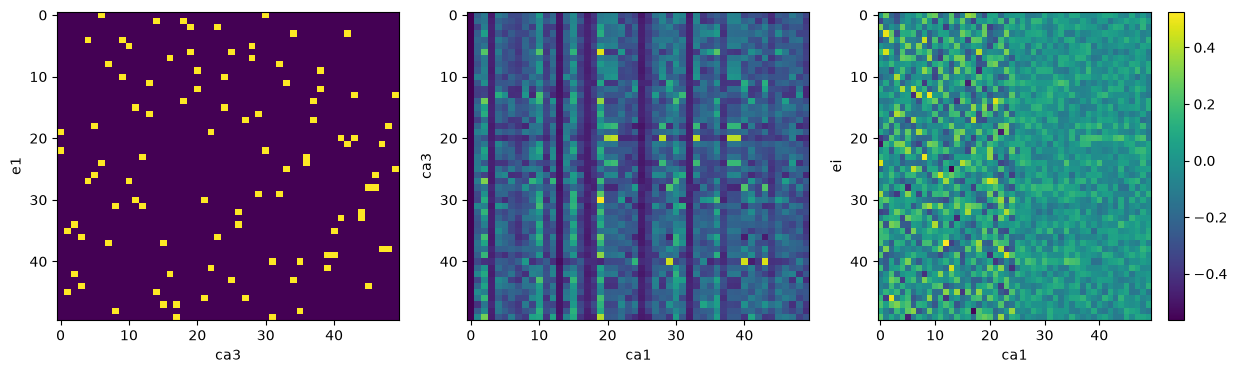

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(5*3, 4))

axs[0].imshow(wca3, aspect="auto")
axs[0].set_ylabel("e1")
axs[0].set_xlabel("ca3")

axs[1].imshow(wca1, aspect="auto")
axs[1].set_ylabel("ca3")
axs[1].set_xlabel("neurons of  ca1")

im = axs[2].imshow(wei, aspect="auto")
axs[2].set_ylabel("ei")
axs[2].set_xlabel("ca1")

plt.colorbar(im)
plt.show()